In [1]:
# %load_ext cuml.accel
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据集

In [2]:
user_data = pd.read_csv('data/JD_IJCAI 19/user')
item_data = pd.read_csv('data/JD_IJCAI 19/item_info')
user_click_data = pd.read_csv('data/JD_IJCAI 19/user_click')
user_order_data = pd.read_csv('data/JD_IJCAI 19/user_order')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_18756\3492151259.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  user_click_data = pd.read_csv('data/JD_IJCAI 19/user_click')


In [3]:
# 查看用户数据
user_data.head()

,user_id,gender,age_range
0,0,0,21~25
1,1,0,31~35
2,2,0,26~30
3,3,1,46~50
4,4,1,31~35


In [4]:
# 查看商品数据
item_data.head()

,item_id,cid1,cid2,cid3,cid1_name,cid2_name,cid3_name,brand_code,price,item_name,seg_name
0,100000002008,1315,1345,12015,服饰内衣,内衣,秋衣秋裤,12002.0,199.0,马克华菲保暖内衣 男士秋衣秋裤套装薄款棉质高弹棉毛衫秋冬男生线衣线裤 宝蓝圆领 L,内衣 高弹 男士 套装 秋衣 棉毛衫 宝蓝 线衣 薄款 秋裤 马克华菲 男生 保暖 棉质 线...
1,100000002009,6196,6227,6232,厨具,餐具,一次性用品,57642.0,19.9,乐扣乐扣 PE家用一次性保鲜膜 生鲜食品保鲜薄膜 LBM106*3 (3卷装)20cm*20M,保鲜膜 薄膜 20cm 生鲜 pe 保鲜 家用 20m 食品 卷装 一次性 乐扣乐扣
2,100000002011,6196,6227,6232,厨具,餐具,一次性用品,57642.0,18.9,乐扣乐扣 PE生鲜水果用一次性保鲜膜 厨房家用保鲜薄膜 LBM105*2(两卷装)30cm*20M,20m 保鲜 厨房 生鲜水果 pe 一次性 薄膜 30cm 乐扣乐扣 两卷装 家用 保鲜膜
3,100000002012,1315,1345,9744,服饰内衣,内衣,男式内裤,8439.0,199.0,花花公子男士内裤冰丝平角内裤男网眼透气弹力中腰四角裤男 4条装5370多色L,男士 弹力 多色 中腰 网眼 内裤 透气 冰丝 花花公子 四角裤 平角 4条装
4,100000002013,6196,11143,11153,厨具,茶具,茶具配件,18922.0,79.0,雅集智能恒温宝 加热保温茶杯垫 玻璃杯垫暖奶器茶具电热保温底座,雅集 茶杯垫 加热 电热 茶具 暖奶器 杯垫 保温 恒温宝 底座 玻璃 智能


In [5]:
# 查看点击数据
user_click_data.head()

,user_id,item_id,datetime,dt
0,0,1150551,2018-06-10 21:41:31,2018-06-10
1,0,11133236,2018-06-10 22:15:15,2018-06-10
2,0,6888601,2018-06-10 21:57:31,2018-06-10
3,0,5812383,2018-06-10 21:40:22,2018-06-10
4,0,4803330,2018-06-10 21:40:07,2018-06-10


In [6]:
# 查看订单数据
user_order_data.head()

,user_id,item_id,count,datetime,dt
0,0,4803330,2,2018-06-10 22:11:02,2018-06-10
1,0,6743054,1,2018-06-10 22:11:02,2018-06-10
2,0,4803334,2,2018-06-10 22:11:02,2018-06-10
3,0,6888601,1,2018-06-10 22:11:02,2018-06-10
4,0,2518073,2,2018-06-10 22:11:02,2018-06-10


# 数据基本信息


In [7]:
print('用户数据形状:', user_data.shape)
print('用户数据列:', user_data.columns.tolist())
print('商品数据形状:', item_data.shape)
print('商品数据列:', item_data.columns.tolist())
print('点击数据形状:', user_click_data.shape)
print('点击数据列:', user_click_data.columns.tolist())
print('订单数据形状:', user_order_data.shape)
print('订单数据列:', user_order_data.columns.tolist())

用户数据形状: (100000, 3)
用户数据列: ['user_id', 'gender', 'age_range']
商品数据形状: (6827234, 11)
商品数据列: ['item_id', 'cid1', 'cid2', 'cid3', 'cid1_name', 'cid2_name', 'cid3_name', 'brand_code', 'price', 'item_name', 'seg_name']
点击数据形状: (52983323, 4)
点击数据列: ['user_id', 'item_id', 'datetime', 'dt']
订单数据形状: (1458498, 5)
订单数据列: ['user_id', 'item_id', 'count', 'datetime', 'dt']


In [8]:
# 数据完整性验证
print('商品数据缺失值:')
print(item_data.isnull().sum())
print('缺失率:')
print(item_data.isnull().sum() / len(item_data) * 100)

商品数据缺失值:
item_id             0
cid1                0
cid2                0
cid3                0
cid1_name           0
cid2_name           0
cid3_name           0
brand_code      37427
price         2050186
item_name           1
seg_name       856682
dtype: int64
缺失率:
item_id        0.000000
cid1           0.000000
cid2           0.000000
cid3           0.000000
cid1_name      0.000000
cid2_name      0.000000
cid3_name      0.000000
brand_code     0.548202
price         30.029526
item_name      0.000015
seg_name      12.548010
dtype: float64


In [9]:
# 数据质量评估
print('用户数据基本统计:')
print(user_data.describe())
print('商品数据基本统计:')
print(item_data.describe())
print('点击数据基本统计:')
print(user_click_data.describe())
print('订单数据基本统计:')
print(user_order_data.describe())

用户数据基本统计:
             user_id         gender
count  100000.000000  100000.000000
mean    49999.500000       0.405000
std     28867.657797       0.490894
min         0.000000       0.000000
25%     24999.750000       0.000000
50%     49999.500000       0.000000
75%     74999.250000       1.000000
max     99999.000000       1.000000
商品数据基本统计:
            item_id          cid1          cid2          cid3    brand_code  \
count  6.827234e+06  6.827234e+06  6.827234e+06  6.827234e+06  6.789807e+06   
mean   2.154335e+10  4.862532e+03  6.390071e+03  8.372509e+03  1.205616e+05   
std    1.664265e+10  4.847746e+03  5.173076e+03  4.784336e+03  1.132162e+05   
min    1.000120e+05  1.730000e+02  1.810000e+02  4.340000e+02 -1.000000e+00   
25%    1.102751e+10  1.315000e+03  1.343000e+03  3.982000e+03  1.504200e+04   
50%    2.360775e+10  1.620000e+03  6.167000e+03  9.733000e+03  8.625600e+04   
75%    2.998756e+10  9.192000e+03  1.173100e+04  1.204700e+04  2.122610e+05   
max    2.001248e+11  1.7

# 数据清洗与 price 缺失处理

In [ ]:
# 数据清洗：处理缺失值和异常值

# 1. 处理其他字段的缺失值
# seg_name 字段：使用 item_name 的前几个字符作为替代
item_data['seg_name'] = item_data['seg_name'].fillna(item_data['item_name'].str[:10])

# brand_code 字段：填充为 'unknown'
item_data['brand_code'] = item_data['brand_code'].fillna('unknown')

# 类别字段：填充为 'unknown'
for col in ['cid1', 'cid2', 'cid3']:
    item_data[col] = item_data[col].fillna('unknown')

# 2. 处理 price 字段缺失
item_data['price_missing'] = item_data['price'].isnull().astype(int)

# 确保价格没有负数或0
item_data.loc[item_data['price'] <= 0, 'price'] = np.nan

# 优先使用更细的类目(cid3)和品牌计算中位数
group_stats_fine = item_data.groupby(['cid3', 'brand_code'])['price'].median().reset_index().rename(columns={'price': 'median_fine'})
# 备选：使用一级类目(cid1)和品牌
group_stats_coarse = item_data.groupby(['cid1', 'brand_code'])['price'].median().reset_index().rename(columns={'price': 'median_coarse'})
global_median = item_data['price'].median()

# 依次合并
item_data = item_data.merge(group_stats_fine, on=['cid3', 'brand_code'], how='left')
item_data = item_data.merge(group_stats_coarse, on=['cid1', 'brand_code'], how='left')

# 填充逻辑：cid3中位数 -> cid1中位数 -> 全局中位数
item_data['price'] = item_data['price'].fillna(item_data['median_fine'])
item_data['price'] = item_data['price'].fillna(item_data['median_coarse'])
item_data['price'] = item_data['price'].fillna(global_median)

item_data = item_data.drop(['median_fine', 'median_coarse'], axis=1)

# 3. 处理异常值
upper_limit = item_data['price'].quantile(0.999) 
lower_limit = item_data['price'].quantile(0.001) # 剔除可能极度偏低的价格

item_data['price'] = np.clip(item_data['price'], lower_limit, upper_limit)

print(f"异常值处理完成。价格范围: {item_data['price'].min():.2f} - {item_data['price'].max():.2f}")

处理其他字段缺失值...
处理 price 字段缺失...
处理异常值...
异常值处理完成。价格范围: 1.00 - 77049.50


保持长尾数据的自然分布形态

价格分布统计指标:
         指标             值
0        均值    924.797192
1       中位数    169.000000
2       标准差   3840.228671
3       最小值      1.000000
4       最大值  77049.500000
5    25%分位数     69.000000
6    75%分位数    499.000000
7  99.9%分位数  77049.500000


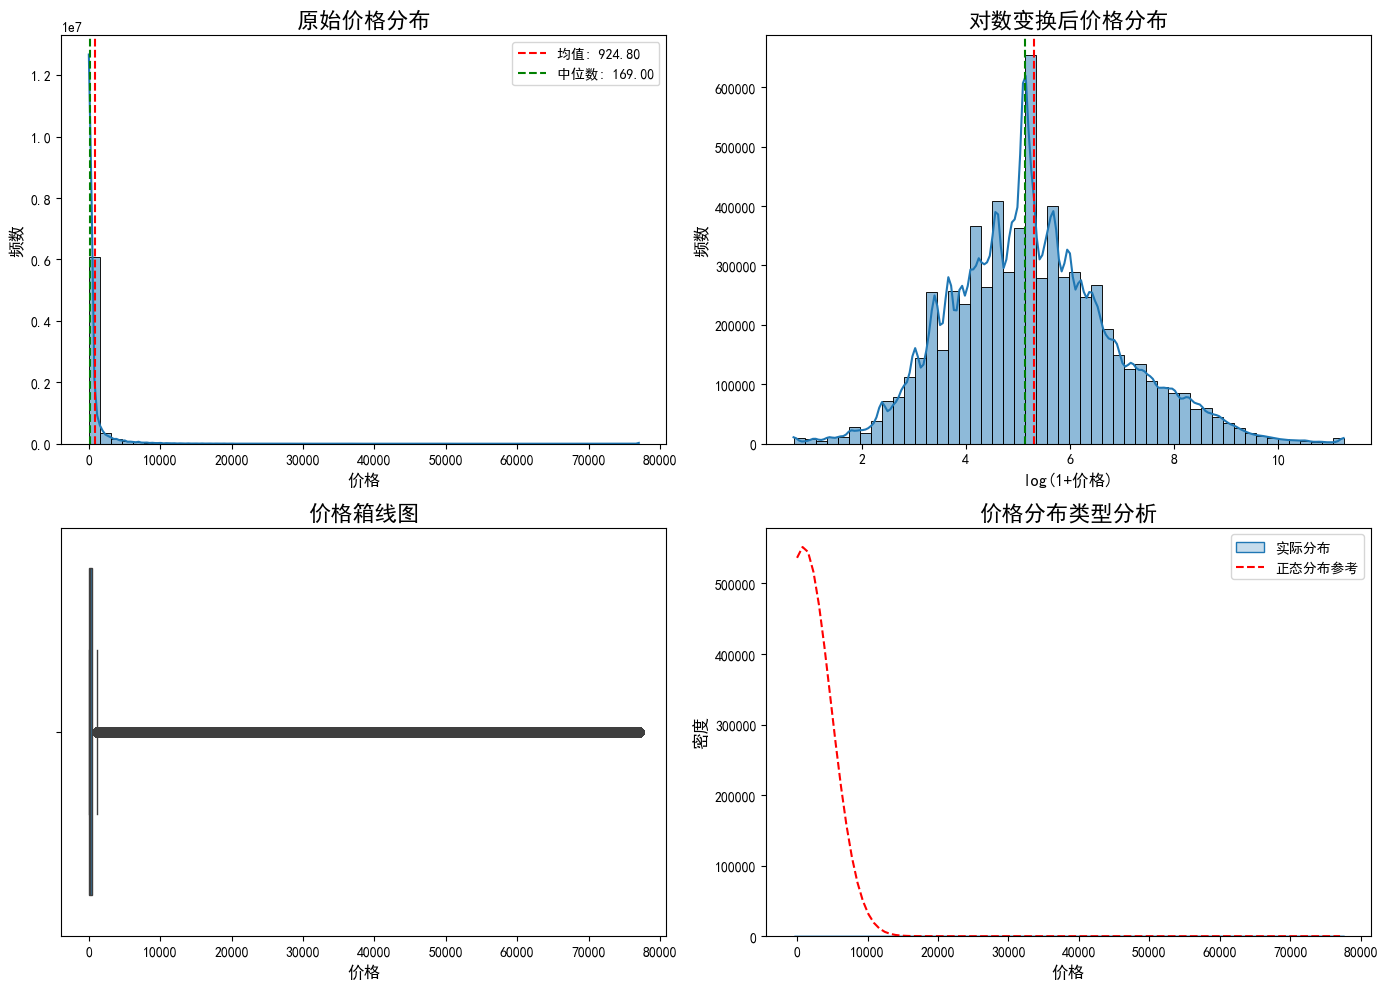

In [11]:
# 1. 直方图与核密度估计
plt.figure(figsize=(14, 10))

# 原始价格分布
plt.subplot(2, 2, 1)
sns.histplot(item_data['price'], bins=50, kde=True)
plt.title('原始价格分布', fontsize=16)
plt.xlabel('价格', fontsize=12)
plt.ylabel('频数', fontsize=12)
plt.axvline(item_data['price'].mean(), color='r', linestyle='--', label=f'均值: {item_data["price"].mean():.2f}')
plt.axvline(item_data['price'].median(), color='g', linestyle='--', label=f'中位数: {item_data["price"].median():.2f}')
plt.legend()

# 对数变换后价格分布
plt.subplot(2, 2, 2)
sns.histplot(np.log1p(item_data['price']), bins=50, kde=True)
plt.title('对数变换后价格分布', fontsize=16)
plt.xlabel('log(1+价格)', fontsize=12)
plt.ylabel('频数', fontsize=12)
plt.axvline(np.log1p(item_data['price']).mean(), color='r', linestyle='--')
plt.axvline(np.log1p(item_data['price']).median(), color='g', linestyle='--')

# 2. 箱线图分析
plt.subplot(2, 2, 3)
sns.boxplot(x=item_data['price'])
plt.title('价格箱线图', fontsize=16)
plt.xlabel('价格', fontsize=12)

# 3. 价格分布统计指标
stats_df = pd.DataFrame({
    '指标': ['均值', '中位数', '标准差', '最小值', '最大值', '25%分位数', '75%分位数', '99.9%分位数'],
    '值': [
        item_data['price'].mean(),
        item_data['price'].median(),
        item_data['price'].std(),
        item_data['price'].min(),
        item_data['price'].max(),
        item_data['price'].quantile(0.25),
        item_data['price'].quantile(0.75),
        item_data['price'].quantile(0.999)
    ]
})
print("价格分布统计指标:")
print(stats_df)

# 4. 价格分布类型分析
plt.subplot(2, 2, 4)
sns.kdeplot(item_data['price'], label='实际分布', fill=True)
# 绘制正态分布参考线
x = np.linspace(item_data['price'].min(), item_data['price'].max(), 100)
y = (1/(item_data['price'].std() * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - item_data['price'].mean())/item_data['price'].std())**2)
plt.plot(x, y * len(item_data) * (x[1]-x[0]), 'r--', label='正态分布参考')
plt.title('价格分布类型分析', fontsize=16)
plt.xlabel('价格', fontsize=12)
plt.ylabel('密度', fontsize=12)
plt.legend()

plt.tight_layout()
plt.savefig('price_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
item_data.to_csv('data/JD_IJCAI 19/item_data_cleaned.csv', index=False)

# 数据入库